<a href="https://colab.research.google.com/github/cmunozr/2026_I_AI_GU/blob/main/Exercises/ex1_intro_ScikitLearn.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Exercise 1 in NGEO316 (my version)

My notebook lives in github, so I will need to clone the entire repository.

In [16]:
!git clone https://github.com/cmunozr/2026_I_AI_GU.git

Cloning into '2026_I_AI_GU'...
remote: Enumerating objects: 45, done.
remote: Counting objects: 100% (45/45), done.
remote: Compressing objects: 100% (34/34), done.
remote: Total 45 (delta 16), reused 24 (delta 6), pack-reused 0 (from 0)
Receiving objects: 100% (45/45), 10.30 KiB | 10.30 MiB/s, done.
Resolving deltas: 100% (16/16), done.


In [29]:
%cd /2026_I_AI_GU
# Configure Git username
!git config user.name "cmunozr"
# Configure Git email
!git config user.email "cmunozbiol@gmail.com"


/2026_I_AI_GU


Starting

In [33]:
# Python ≥3.7 is required
import sys
assert sys.version_info >= (3, 7) # interesting function
print("Python version:", sys.version)

# Scikit-Learn ≥1.0.1 is required
from packaging import version
import sklearn
assert version.parse(sklearn.__version__) >= version.parse("1.0.1")
print("Scikitlearn version:", sklearn.__version__)

# Common imports NumPy and Pandas
import numpy as np
print("NumPy version:", np.__version__)
import os as os
import pandas as pd
print("pandas version:", pd.__version__)
from sklearn.preprocessing import OneHotEncoder

# To plot pretty figures
%matplotlib inline
import matplotlib as mpl
import matplotlib.pyplot as plt
mpl.rc('axes', labelsize=14)
mpl.rc('xtick', labelsize=12)
mpl.rc('ytick', labelsize=12)
print("matplotlib version:", mpl.__version__)

Python version: 3.12.13 (main, Mar  4 2026, 09:23:07) [GCC 11.4.0]
Scikitlearn version: 1.6.1
NumPy version: 2.0.2
pandas version: 2.2.2
matplotlib version: 3.10.0


Helper functions

In [21]:
# THIS FUNCTION WILL DIRECT WHERE TO SAVE ANY FIGURES CREATED
PROJECT_ROOT_DIR = "."
CHAPTER_ID = "end_to_end_project"
IMAGES_PATH = os.path.join(PROJECT_ROOT_DIR, "images", CHAPTER_ID)
os.makedirs(IMAGES_PATH, exist_ok=True)

# Set the data path
datapath = os.path.join("datasets", "lifesat", "")

# Define a function called save-fig
def save_fig(fig_id, tight_layout=True, fig_extension="png", resolution=300):
    path = os.path.join(IMAGES_PATH, fig_id + "." + fig_extension)
    print("Saving figure", fig_id)
    if tight_layout:
        plt.tight_layout()
    plt.savefig(path, format=fig_extension, dpi=resolution)

Now let's "pip install" tqdm which will allow us to have a progress bar show when we run functions

In [19]:
# Import tqdm for progress bar
#May not be needed in Google Colab, but doesn't hurt either
!pip install tqdm
from tqdm import tqdm

## Basics

Creating an array in numpy (list of lists) elements of a single data type, it is fixed, and optimized for operations

In [22]:
x = np.array([[1,2,3],[4,5,6],[7,8,9]])
print("x:\n{}".format(x))

x:
[[1 2 3]
 [4 5 6]
 [7 8 9]]


Sparse 2D array with a diagonal of ones, with zeros everywhere else (has a few non-zero values scattered among a large number of zeros). It allows for specialized storage and computational techniques that can be much more efficient than traditional dense matrix operation

In [23]:
from scipy import sparse
mysparse_matrix = np.eye(4)
print("NumPy array:\n", mysparse_matrix)

NumPy array:
 [[1. 0. 0. 0.]
 [0. 1. 0. 0.]
 [0. 0. 1. 0.]
 [0. 0. 0. 1.]]


DataFrame in Pandas. Pandas is built on top of NumPy for (data manipulation, analysis, and cleaning). Structured data, including reading/writing from various file formats (CSV, Excel, SQL, etc.).

In [24]:
# Create a DataFrame
age = [['Bill', 95.5, "Male"],
       ['Britt', 65.7, "Female"],
       ['Joe', 85.1, "Male"],
       ['Stan', 75.4, "Male"]]
df = pd.DataFrame(age, columns=['Name', 'Marks', 'Gender'])
print(df)

    Name  Marks  Gender
0   Bill   95.5    Male
1  Britt   65.7  Female
2    Joe   85.1    Male
3   Stan   75.4    Male


Reading Iris

In [31]:
iris_df = pd.read_csv('./Exercises/iris.csv')
print(iris_df)

     sepal.length  sepal.width  petal.length  petal.width    variety
0             5.1          3.5           1.4          0.2     Setosa
1             4.9          3.0           1.4          0.2     Setosa
2             4.7          3.2           1.3          0.2     Setosa
3             4.6          3.1           1.5          0.2     Setosa
4             5.0          3.6           1.4          0.2     Setosa
..            ...          ...           ...          ...        ...
145           6.7          3.0           5.2          2.3  Virginica
146           6.3          2.5           5.0          1.9  Virginica
147           6.5          3.0           5.2          2.0  Virginica
148           6.2          3.4           5.4          2.3  Virginica
149           5.9          3.0           5.1          1.8  Virginica

[150 rows x 5 columns]


## ML Project with Housing data

Download and read the California housing data

In [32]:
from pathlib import Path
import tarfile
import urllib.request

def load_housing_data():
    tarball_path = Path("datasets/housing.tgz")
    if not tarball_path.is_file():
        Path("datasets").mkdir(parents=True, exist_ok=True)
        url = "https://github.com/ageron/data/raw/main/housing.tgz"
        urllib.request.urlretrieve(url, tarball_path)
    with tarfile.open(tarball_path) as housing_tarball:
            housing_tarball.extractall(path="datasets")
    return pd.read_csv(Path("datasets/housing/housing.csv"))

housing = load_housing_data()

/tmp/ipykernel_1987/3712241232.py:12: DeprecationWarning: Python 3.14 will, by default, filter extracted tar archives and reject files or modify their metadata. Use the filter argument to control this behavior.
  housing_tarball.extractall(path="datasets")


In [34]:
housing.head()

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value,ocean_proximity
0,-122.23,37.88,41.0,880.0,129.0,322.0,126.0,8.3252,452600.0,NEAR BAY
1,-122.22,37.86,21.0,7099.0,1106.0,2401.0,1138.0,8.3014,358500.0,NEAR BAY
2,-122.24,37.85,52.0,1467.0,190.0,496.0,177.0,7.2574,352100.0,NEAR BAY
3,-122.25,37.85,52.0,1274.0,235.0,558.0,219.0,5.6431,341300.0,NEAR BAY
4,-122.25,37.85,52.0,1627.0,280.0,565.0,259.0,3.8462,342200.0,NEAR BAY


## Looking the structure

In [35]:
print(housing.shape) # dimensions of the data frame

(20640, 10)


In [36]:
housing.info() #

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20640 entries, 0 to 20639
Data columns (total 10 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   longitude           20640 non-null  float64
 1   latitude            20640 non-null  float64
 2   housing_median_age  20640 non-null  float64
 3   total_rooms         20640 non-null  float64
 4   total_bedrooms      20433 non-null  float64
 5   population          20640 non-null  float64
 6   households          20640 non-null  float64
 7   median_income       20640 non-null  float64
 8   median_house_value  20640 non-null  float64
 9   ocean_proximity     20640 non-null  object 
dtypes: float64(9), object(1)
memory usage: 1.6+ MB


In [37]:
housing["ocean_proximity"].value_counts() # int64 is the 64bit version for integers

,count
ocean_proximity,
<1H OCEAN,9136
INLAND,6551
NEAR OCEAN,2658
NEAR BAY,2290
ISLAND,5


In [38]:
housing.describe() # it is like summary

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value
count,20640.000000,20640.000000,20640.000000,20640.000000,20433.000000,20640.000000,20640.000000,20640.000000,20640.000000
mean,-119.569704,35.631861,28.639486,2635.763081,537.870553,1425.476744,499.539680,3.870671,206855.816909
std,2.003532,2.135952,12.585558,2181.615252,421.385070,1132.462122,382.329753,1.899822,115395.615874
min,-124.350000,32.540000,1.000000,2.000000,1.000000,3.000000,1.000000,0.499900,14999.000000
25%,-121.800000,33.930000,18.000000,1447.750000,296.000000,787.000000,280.000000,2.563400,119600.000000
50%,-118.490000,34.260000,29.000000,2127.000000,435.000000,1166.000000,409.000000,3.534800,179700.000000
75%,-118.010000,37.710000,37.000000,3148.000000,647.000000,1725.000000,605.000000,4.743250,264725.000000
max,-114.310000,41.950000,52.000000,39320.000000,6445.000000,35682.000000,6082.000000,15.000100,500001.000000


Saving figure attribute_histogram_plots


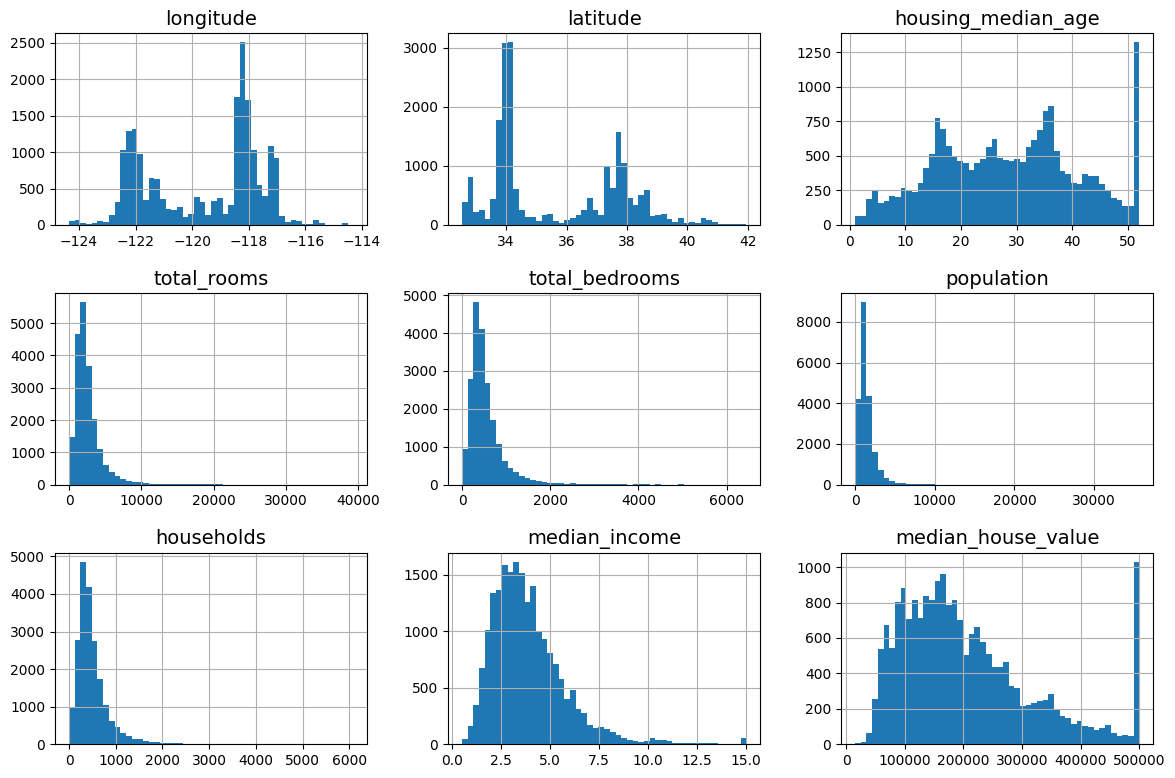

In [39]:
%matplotlib inline (Jupyter magic command that makes matplotlib plots appear directly within your notebook output cells, right below the code that generated them)
import matplotlib.pyplot as plt

# extra code – the next 5 lines define the default font sizes
plt.rc('font', size=14)
plt.rc('axes', labelsize=14, titlesize=14)
plt.rc('legend', fontsize=14)
plt.rc('xtick', labelsize=10)
plt.rc('ytick', labelsize=10)

housing.hist(bins=50, figsize=(12, 8))
save_fig("attribute_histogram_plots")  # extra code
plt.show()

## Split data into test and training with Scikit-learn

Select a random seed for comparison and reproducibility

In [42]:
np.random.seed(42)

Important: **You want to make sure that your test set is representative of the range of incomes in the whole data set** Example with median_income. Plot and understand the values.

<Axes: >

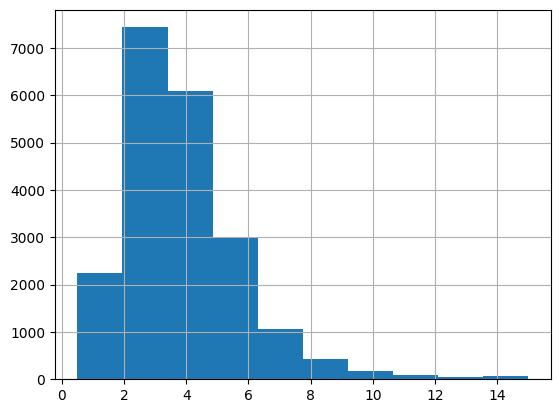

In [44]:
housing["median_income"].hist()

We want to also create a categorical feature of "Income Category". So we create a new feature called "income_cat" which we derive from the existing feature "median income".

In [45]:
# The pd.cut function creates the number of classes with the following bins
housing["income_cat"] = pd.cut(housing["median_income"],
                               bins=[0., 1.5, 3.0, 4.5, 6., np.inf],
                               labels=[1, 2, 3, 4, 5])

In [46]:
housing["income_cat"].value_counts()

,count
income_cat,
3,7236
2,6581
4,3639
5,2362
1,822


Saving figure housing_income_cat_bar_plot


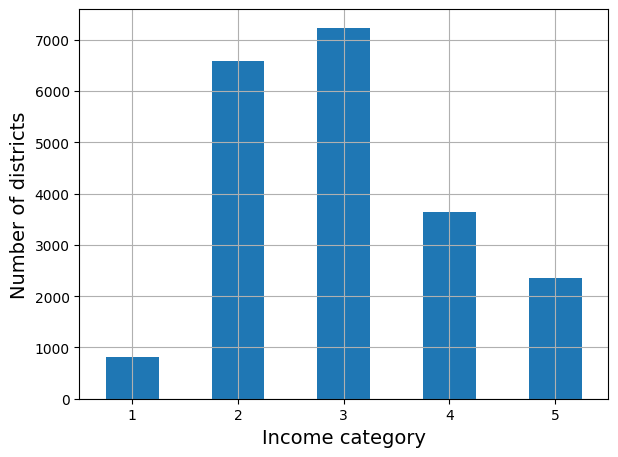

In [47]:
housing["income_cat"].value_counts().sort_index().plot.bar(rot=0, grid=True)
plt.xlabel("Income category")
plt.ylabel("Number of districts")
save_fig("housing_income_cat_bar_plot")  # extra code
plt.show()

Stratified sampling of train and test based on the income category class. Use Scikit-learns StratifiedShuffleSplit class

In [49]:
from sklearn.model_selection import StratifiedShuffleSplit

split = StratifiedShuffleSplit(n_splits=1, test_size=0.2, random_state=42)
for train_index, test_index in split.split(housing, housing["income_cat"]):
    strat_train_set = housing.loc[train_index]
    strat_test_set = housing.loc[test_index]

Now draw the proportions in the test set

In [50]:
strat_test_set["income_cat"].value_counts() / len(strat_test_set)

,count
income_cat,
3,0.350533
2,0.318798
4,0.176357
5,0.114341
1,0.039971


This is how proportions look in the whole dataset

In [51]:
housing["income_cat"].value_counts() / len(housing)

,count
income_cat,
3,0.350581
2,0.318847
4,0.176308
5,0.114438
1,0.039826


Comparing with a completely random selection of the train and test

In [52]:
def income_cat_proportions(data):
    return data["income_cat"].value_counts() / len(data)
#from sklearn.model_selection import train_test_split
train_set, test_set = train_test_split(housing, test_size=0.2, random_state=42)

compare_props = pd.DataFrame({
    "Overall %": income_cat_proportions(housing),
    "Stratified %": income_cat_proportions(strat_test_set),
    "Random %": income_cat_proportions(test_set),
}).sort_index()
compare_props.index.name = "Income Category"
compare_props["Strat. Error %"] = (compare_props["Stratified %"] /
                                   compare_props["Overall %"] - 1)
compare_props["Rand. Error %"] = (compare_props["Random %"] /
                                  compare_props["Overall %"] - 1)
(compare_props * 100).round(2)

,Overall %,Stratified %,Random %,Strat. Error %,Rand. Error %
Income Category,,,,,
1,3.98,4.00,4.24,0.36,6.45
2,31.88,31.88,30.74,-0.02,-3.59
3,35.06,35.05,34.52,-0.01,-1.53
4,17.63,17.64,18.41,0.03,4.42
5,11.44,11.43,12.09,-0.08,5.63


In this case the categorical variable will removed and not used as a feature in modelling

In [ ]:
for set_ in (strat_train_set, strat_test_set):
    set_.drop("income_cat", axis=1, inplace=True)

## Discover and Visualize the Data to Gain Insights

Make a copy to keep the train set clean

In [ ]:
housing = strat_train_set.copy()

### Visualize spatial data

Lat/Long even allows us to plot a spatial dataset (in the original document they work step by step to get this nice image)

Saving figure california_housing_prices_plot


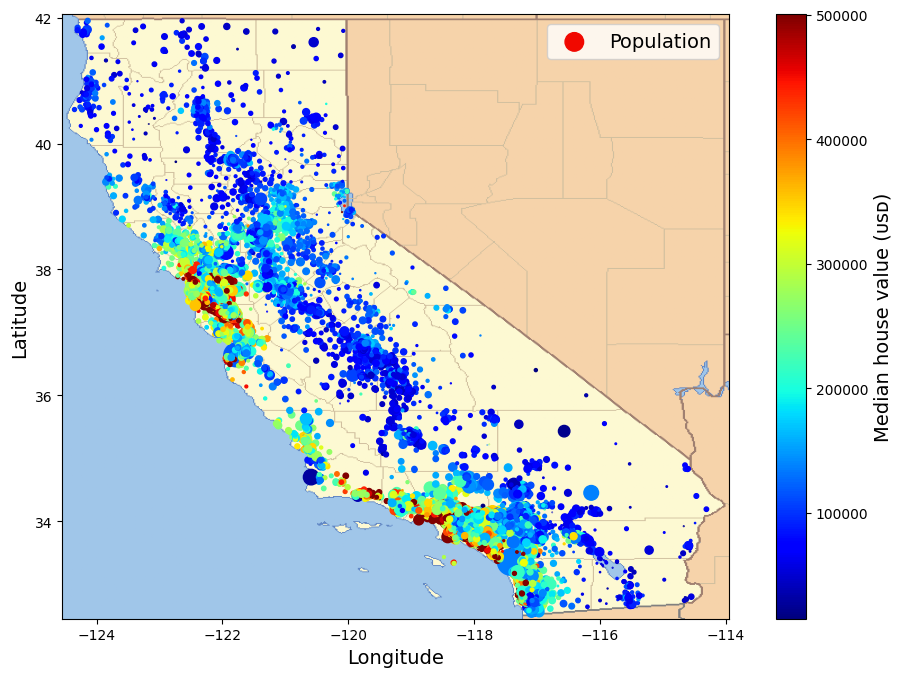

In [57]:
# Download the California image
filename = "california.png"

# Convert IMAGES_PATH to a Path object to use the / operator for path concatenation
from pathlib import Path
images_path_obj = Path(IMAGES_PATH)

if not (images_path_obj / filename).is_file():
    homl3_root = "https://github.com/ageron/handson-ml3/raw/main/"
    url = homl3_root + "images/end_to_end_project/" + filename
    print("Downloading", filename)
    urllib.request.urlretrieve(url, images_path_obj / filename)

housing_renamed = housing.rename(columns={
    "latitude": "Latitude", "longitude": "Longitude",
    "population": "Population",
    "median_house_value": "Median house value (ᴜsᴅ)"})
housing_renamed.plot(
             kind="scatter", x="Longitude", y="Latitude",
             s=housing_renamed["Population"] / 100, label="Population",
             c="Median house value (ᴜsᴅ)", cmap="jet", colorbar=True,
             legend=True, sharex=False, figsize=(10, 7))

california_img = plt.imread(images_path_obj / filename)
axis = -124.55, -113.95, 32.45, 42.05
plt.axis(axis)
plt.imshow(california_img, extent=axis)

save_fig("california_housing_prices_plot")
plt.show()

### Looking for Correlations

In [58]:
corr_matrix = housing.corr(numeric_only=True)
print('Correlation Matrix for Median House Value:')
corr_matrix["median_house_value"].sort_values(ascending=False)

Correlation Matrix for Median House Value:


,median_house_value
median_house_value,1.000000
median_income,0.688075
total_rooms,0.134153
housing_median_age,0.105623
households,0.065843
total_bedrooms,0.049686
population,-0.024650
longitude,-0.045967
latitude,-0.144160


Plot variables/attributes against each other in scatter plots. The following uses pandas scatter_matrix function to plot all given attributes

Saving figure scatter_matrix_plot


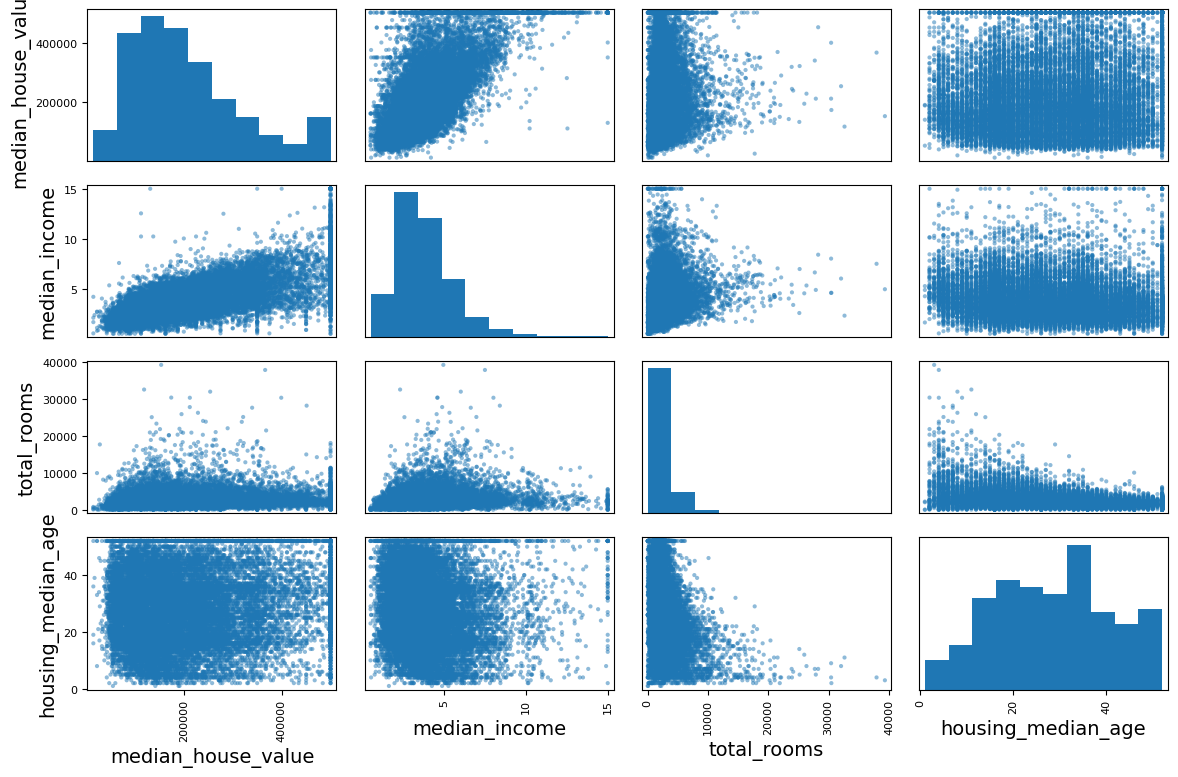

In [59]:

# from pandas.tools.plotting import scatter_matrix # For older versions of Pandas
from pandas.plotting import scatter_matrix

attributes = ["median_house_value", "median_income", "total_rooms",
              "housing_median_age"]
scatter_matrix(housing[attributes], figsize=(12, 8))
save_fig("scatter_matrix_plot")
plt.show()


Zoom to Median Income as it has highest correlation

Saving figure income_vs_house_value_scatterplot


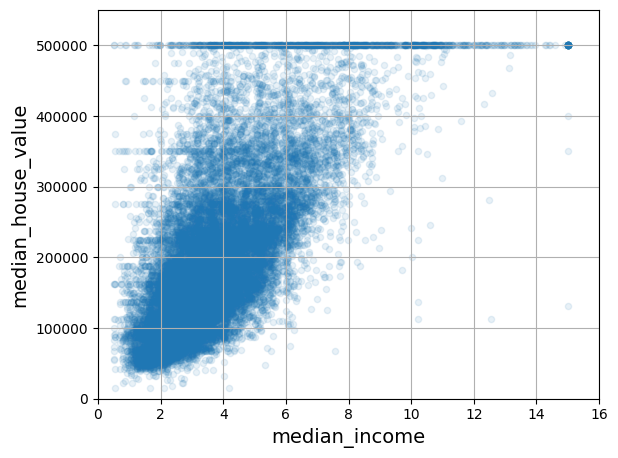

In [60]:
housing.plot(kind="scatter", x="median_income", y="median_house_value",
             alpha=0.1, grid=True)
plt.axis([0, 16, 0, 550000])
save_fig("income_vs_house_value_scatterplot")
plt.show()

### Experimenting with Attribute Combinations

You may want to **experiment with creating new variables which may be more meaningful.** For example, knowing the number of rooms by household may be more useful than just the total number of rooms in a district.

In [61]:
housing["rooms_per_household"] = housing["total_rooms"]/housing["households"]
housing["bedrooms_per_room"] = housing["total_bedrooms"]/housing["total_rooms"]
housing["population_per_household"]=housing["population"]/housing["households"]

In [62]:
#You have run a correlation matrix before, but this one will have the new features
corr_matrix = housing.corr(numeric_only=True)
corr_matrix["median_house_value"].sort_values(ascending=False)

,median_house_value
median_house_value,1.000000
median_income,0.688075
rooms_per_household,0.151948
total_rooms,0.134153
housing_median_age,0.105623
households,0.065843
total_bedrooms,0.049686
population_per_household,-0.023737
population,-0.024650
longitude,-0.045967


## Prepare the Data for ML

Separate the predictors and the labels. We don't want to apply the same transformation to both

In [ ]:
housing = strat_train_set.drop("median_house_value", axis=1) # drop labels for training set
housing_labels = strat_train_set["median_house_value"].copy()

### Data Cleaning

The original code present several options about the NULL data. Option 1 is to remove the observations with null, option 2 is remove all the variable/feature and option 3 is imputing with other value (median, mean, 0).

Here I will copy the use of Scikit-Learns "Simple Imputer" to take care of missing values

#### *Numerical variables imputation*

We need to walk around the categorical variables first

In [64]:
housing_num = housing.select_dtypes(include=[np.number])

First search for the null

In [75]:
null_rows_idx = housing.isnull().any(axis=1)

load the imputer and give it the strategy

In [66]:
from sklearn.impute import SimpleImputer
imputer = SimpleImputer(strategy="median")

Fit the data into the imputer

In [68]:
imputer.fit(housing_num)

SimpleImputer(strategy='median')

Lets check the statistics of the imputer

In [69]:
imputer.statistics_

array([-1.18490000e+02,  3.42600000e+01,  2.90000000e+01,  2.12700000e+03,
        4.35000000e+02,  1.16600000e+03,  4.09000000e+02,  3.53480000e+00,
        1.79700000e+05,  5.22912879e+00,  2.03162434e-01,  2.81811565e+00])

Apply the imputer into the data

In [71]:
X = imputer.transform(housing_num)

The imputer saves information from the data

In [72]:
imputer.feature_names_in_

array(['longitude', 'latitude', 'housing_median_age', 'total_rooms',
       'total_bedrooms', 'population', 'households', 'median_income',
       'median_house_value', 'rooms_per_household', 'bedrooms_per_room',
       'population_per_household'], dtype=object)

In [73]:
housing_tr = pd.DataFrame(X, columns=housing_num.columns,
                          index=housing_num.index)

In [76]:
housing_tr.loc[null_rows_idx].head()

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value,rooms_per_household,bedrooms_per_room,population_per_household
182,-118.27,34.04,13.0,1784.0,435.0,2158.0,682.0,1.7038,118100.0,2.615836,0.203162,3.164223
327,-117.65,34.04,15.0,3393.0,435.0,2039.0,611.0,3.9336,151000.0,5.553191,0.203162,3.337152
366,-122.50,37.75,44.0,1819.0,435.0,1137.0,354.0,3.4919,271800.0,5.138418,0.203162,3.211864
477,-117.99,34.14,30.0,2346.0,435.0,1988.0,474.0,2.5625,153000.0,4.949367,0.203162,4.194093
495,-114.59,34.83,41.0,812.0,435.0,375.0,158.0,1.7083,48500.0,5.139241,0.203162,2.373418


#### *Outliers*

Here we use a model. IsolationForest is an unsupervised machine learning algorithm used for anomaly (outlier) detection. It works by building an ensemble of isolation trees, much like a Random Forest builds decision trees

In [77]:
from sklearn.ensemble import IsolationForest

isolation_forest = IsolationForest(random_state=42)
outlier_pred = isolation_forest.fit_predict(X)

In [78]:
outlier_pred

array([ 1, -1,  1, ...,  1,  1,  1])

To drop the outliers

In [ ]:
housing = housing.iloc[outlier_pred == 1]
housing_labels = housing_labels.iloc[outlier_pred == 1]

#### *Handling Text and Categorical Attributes*

Now let's preprocess the categorical input feature, ocean_proximity:

In [79]:
housing_cat = housing[["ocean_proximity"]]
housing_cat.head(10)

,ocean_proximity
0,NEAR BAY
1,NEAR BAY
2,NEAR BAY
3,NEAR BAY
4,NEAR BAY
5,NEAR BAY
6,NEAR BAY
7,NEAR BAY
8,NEAR BAY
9,NEAR BAY


In the original code they give two options: ordinal enconder and hot encoder. The ordinal gives a number from 1 to n categories but a model would probably understand it as measure of closeness. This is why we perefer a hot encoder in this case as this is not really a scale (Ordinal encoder assumes a relationship between the numbers (eg, that 1 is closer to 2))

In [82]:
from sklearn.preprocessing import OneHotEncoder

cat_encoder = OneHotEncoder()
housing_cat_1hot = cat_encoder.fit_transform(housing_cat)
housing_cat_1hot

# we can convert it to a dense array (which uses a more efficient storage of 0 values) if needed by calling the toarray() method
housing_cat_1hot.toarray()

array([[0., 0., 0., 1., 0.],
       [0., 0., 0., 1., 0.],
       [0., 0., 0., 1., 0.],
       ...,
       [0., 1., 0., 0., 0.],
       [0., 1., 0., 0., 0.],
       [0., 1., 0., 0., 0.]])

## Feature Scaling

In [ ]:
# Assuming your figures are saved in the 'images/end_to_end_project' directory relative to your repository root
!git add images/end_to_end_project/

# Commit the changes
!git commit -m "Add generated figures"

# Push the changes to your remote repository (e.g., 'origin' and 'main' branch)
# You will be prompted for your GitHub username and Personal Access Token (PAT)
!git push origin main